In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import joblib # Buat simpan model nanti

In [2]:
# ==============================================================================
# 1. KONFIGURASI
# ==============================================================================
FOLDER = '/kaggle/input/datasets/jerismeteo/open-meteo-data-kebumen/open_meteo_jerukagung'
FILE = 'cuaca_jerukagung.csv'


In [3]:
# ==============================================================================
# 2. LOAD DATA & BERSIHKAN WAKTU
# ==============================================================================
def load_data(filepath):
    print(f"Membaca file: {filepath}")
    if not os.path.exists(filepath):
        print("File tidak ditemukan.")
        return None
    
    # Baca CSV
    df = pd.read_csv(filepath, index_col='date', parse_dates=True)
    
    # Perbaikan Zona Waktu (Agar tidak geser)
    # 1. Baca sebagai UTC
    df.index = pd.to_datetime(df.index, utc=True)
    # 2. Geser ke WIB
    df.index = df.index.tz_convert('Asia/Jakarta')
    # 3. Hapus label zona waktu (biar jadi jam dinding polos)
    df.index = df.index.tz_localize(None)
    
    df = df.sort_index()
    print(f"Rentang Data: {df.index.min()} s.d {df.index.max()}")
    return df

path_final = os.path.join(FOLDER, FILE)
df = load_data(path_final)


df.tail(10)

Membaca file: /kaggle/input/datasets/jerismeteo/open-meteo-data-kebumen/open_meteo_jerukagung/cuaca_jerukagung.csv
Rentang Data: 2000-01-01 00:00:00 s.d 2026-02-22 23:00:00


,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
date,,,,,,,,,,
2026-02-22 14:00:00,27.05,87.265330,24.75,2.6,10.837435,281.496520,1003.12920,38.39653,100.0,63.0
2026-02-22 15:00:00,27.00,81.441620,23.55,1.9,7.072878,284.743620,1002.92926,0.00000,100.0,61.0
2026-02-22 16:00:00,26.75,86.717840,24.35,0.4,7.168430,298.495540,1002.72784,0.00000,100.0,51.0
2026-02-22 17:00:00,26.30,90.662210,24.65,0.3,5.369916,283.570430,1002.82450,0.00000,100.0,51.0
2026-02-22 18:00:00,25.95,93.391070,24.80,0.1,1.484318,345.963700,1003.71970,0.00000,100.0,51.0
2026-02-22 19:00:00,25.75,93.381560,24.60,0.1,1.938659,158.198530,1004.51680,0.00000,100.0,51.0
2026-02-22 20:00:00,25.80,89.816550,24.00,0.3,0.509117,135.000100,1005.21550,0.00000,100.0,51.0
2026-02-22 21:00:00,25.50,90.881805,23.90,1.0,0.402492,333.435030,1005.81200,0.00000,100.0,55.0
2026-02-22 22:00:00,25.00,96.189644,24.35,0.4,2.741678,23.198618,1006.10754,0.00000,100.0,51.0


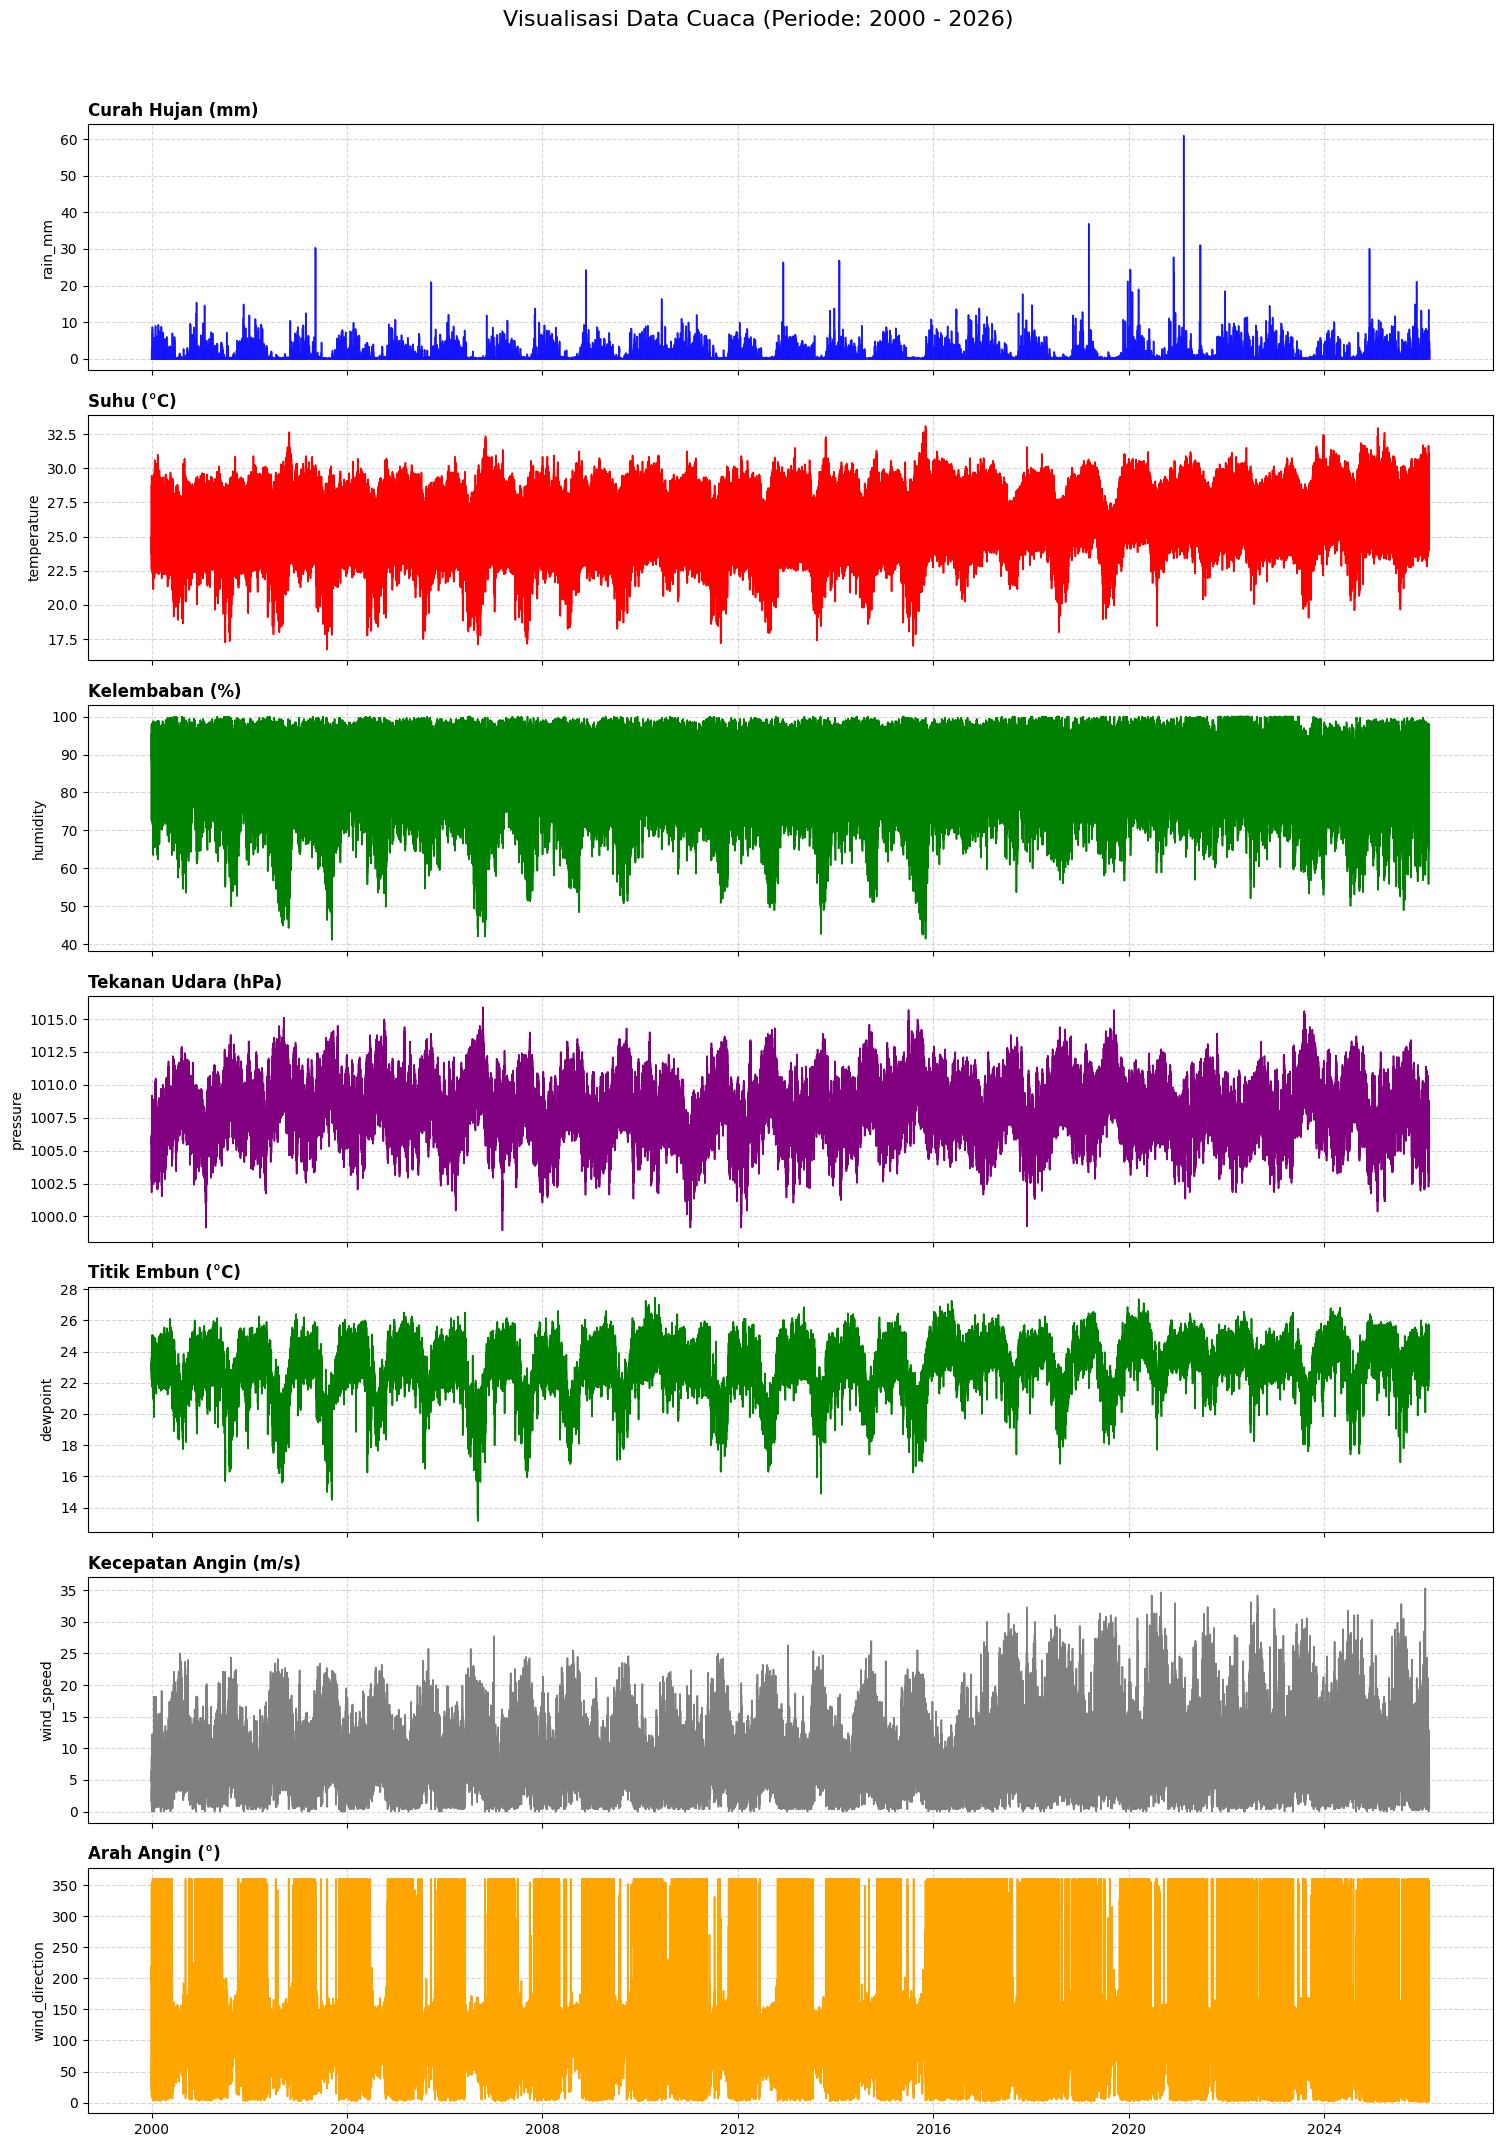

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# VISUALISASI TIME SERIES SEMUA VARIABEL
# =========================================================

# 1. Pilih Kolom yang Mau Di-plot (Otomatis deteksi yang ada)
target_cols = ['rain_mm', 'temperature', 'humidity', 'pressure','dewpoint', 'wind_speed', 'wind_direction']
cols_to_plot = [col for col in target_cols if col in df.columns]

# 2. Atur Ukuran Gambar (Tinggi menyesuaikan jumlah kolom)
n_cols = len(cols_to_plot)
fig, axes = plt.subplots(nrows=n_cols, ncols=1, figsize=(15, 3 * n_cols), sharex=True)

# 3. Definisikan Warna & Style biar Cantik
colors = {
    'rain_mm': 'blue',
    'temperature': 'red',
    'humidity': 'green',
    'pressure': 'purple',
    'dewpoint': 'green',
    'wind_speed': 'grey',
    'wind_direction': 'orange'
}

titles = {
    'rain_mm': 'Curah Hujan (mm)',
    'temperature': 'Suhu (°C)',
    'humidity': 'Kelembaban (%)',
    'pressure': 'Tekanan Udara (hPa)',
    'dewpoint' : 'Titik Embun (°C)',
    'wind_speed': 'Kecepatan Angin (m/s)',
    'wind_direction': 'Arah Angin (°)'
}

# 4. Loop untuk Menggambar Setiap Variabel
for i, col in enumerate(cols_to_plot):
    ax = axes[i] if n_cols > 1 else axes # Handle jika cuma 1 kolom
    
    # Ambil data (Bisa di-slice kalau terlalu berat, misal: df.tail(1000))
    data = df[col] 
    
    # Khusus Hujan pakai Area Plot (Biar kelihatan volume-nya)
    if col == 'rain_mm':
        ax.fill_between(data.index, data, color=colors.get(col, 'blue'), alpha=0.6)
        ax.plot(data.index, data, color=colors.get(col, 'blue'), alpha=0.8, linewidth=1)
    else:
        # Yang lain pakai Garis biasa
        ax.plot(data.index, data, color=colors.get(col, 'black'), linewidth=1.2)
    
    # Kosmetik Grafik
    ax.set_title(titles.get(col, col), fontsize=12, loc='left', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel(col)

# Judul Besar
plt.suptitle(f'Visualisasi Data Cuaca (Periode: {df.index.min().year} - {df.index.max().year})', 
             y=1.02, fontsize=16)

plt.tight_layout()
plt.show()

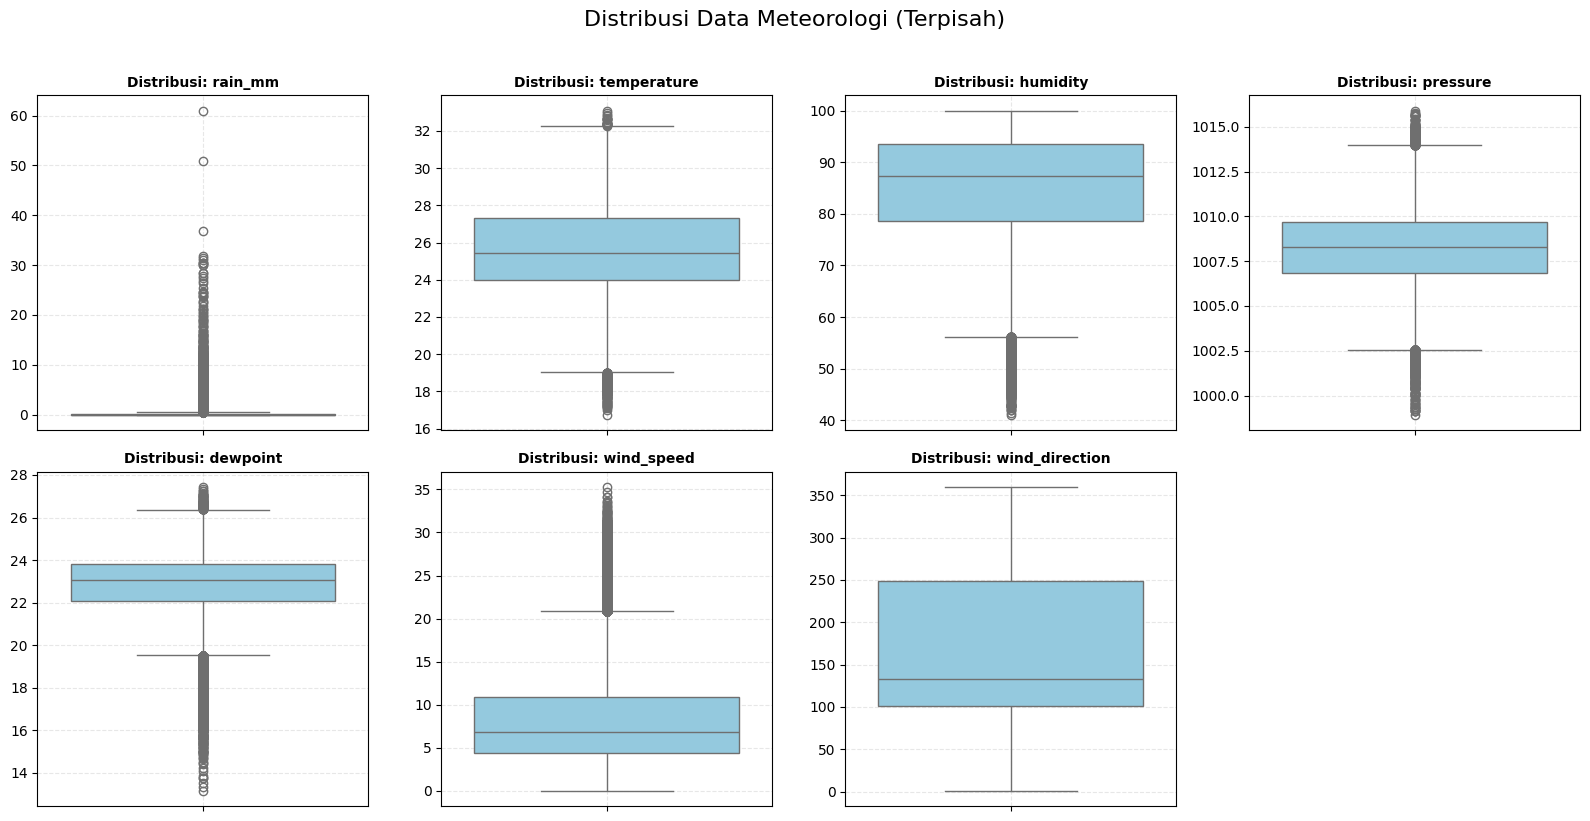

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Tentukan kolom yang mau di-plot
cols = ['rain_mm', 'temperature', 'humidity', 'pressure', 'dewpoint', 'wind_speed', 'wind_direction']

# 2. Hitung jumlah baris dan kolom layout
n_cols = 4  # Mau berapa gambar per baris? (misal 4 ke samping)
n_rows = math.ceil(len(cols) / n_cols) # Hitung otomatis butuh berapa baris ke bawah

# 3. Buat Canvas Besar
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8)) # Atur ukuran kertas
axes = axes.flatten() # Jadikan array 1 dimensi biar gampang di-loop

# 4. Looping untuk gambar satu per satu
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue') # Gambar di kotak ke-i
    axes[i].set_title(f'Distribusi: {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('') # Hapus label Y biar gak penuh
    axes[i].grid(True, alpha=0.3, linestyle='--')

# 5. Hapus kotak kosong (sisa)
for i in range(len(cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Distribusi Data Meteorologi (Terpisah)", fontsize=16, y=1.02)
plt.tight_layout() # Biar gak tumpang tindih
plt.show()

In [6]:
# Ambil data 10 tahun terakhir agar relevan dan training tidak terlalu lama
# (Silakan ubah tahunnya jika mau lebih banyak data)
df_ai = df.loc['2000':'2025'].copy()

In [7]:
df_ai.tail(10)

,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
date,,,,,,,,,,
2025-12-31 14:00:00,28.20,79.185100,24.25,5.3,4.965521,226.468730,1003.83580,0.0,100.0,63.0
2025-12-31 15:00:00,27.10,85.206960,24.40,0.4,5.223103,178.025120,1003.42880,0.0,100.0,51.0
2025-12-31 16:00:00,26.90,86.472466,24.45,0.5,4.680000,112.619910,1003.42725,0.0,100.0,53.0
2025-12-31 17:00:00,26.80,88.029434,24.65,0.1,3.107282,100.007920,1003.72600,0.0,100.0,51.0
2025-12-31 18:00:00,26.30,92.852860,25.05,0.0,1.808978,84.289500,1004.42100,0.0,100.0,3.0
2025-12-31 19:00:00,26.50,89.598580,24.65,0.1,1.094897,279.462250,1005.32043,0.0,100.0,51.0
2025-12-31 20:00:00,26.00,91.734110,24.55,0.0,1.297998,56.309914,1005.81586,0.0,99.0,3.0
2025-12-31 21:00:00,25.75,93.102684,24.55,0.0,0.254558,44.999897,1006.31287,0.0,100.0,3.0
2025-12-31 22:00:00,25.75,94.222496,24.75,0.0,2.448265,323.972530,1006.81177,0.0,100.0,3.0


In [8]:
df_ai.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 227928 entries, 2000-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   temperature        227928 non-null  float64
 1   humidity           227928 non-null  float64
 2   dewpoint           227928 non-null  float64
 3   rain_mm            227928 non-null  float64
 4   wind_speed         227928 non-null  float64
 5   wind_direction     227928 non-null  float64
 6   pressure           227928 non-null  float64
 7   sunshine_duration  227928 non-null  float64
 8   cloud_cover        227928 non-null  float64
 9   weather_code       227928 non-null  float64
dtypes: float64(10)
memory usage: 19.1 MB


Sedang memproses Kalman Filter...
Data berhasil difilter (Smooth & Denoised).


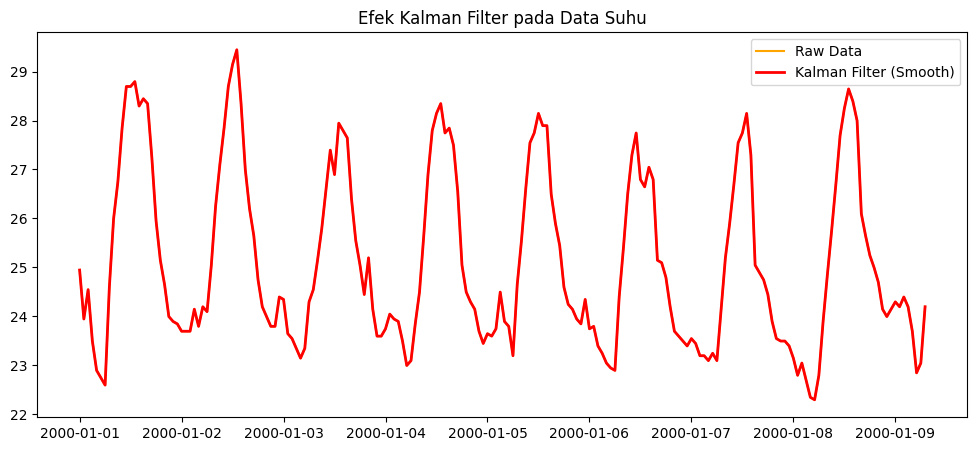

In [9]:
import numpy as np
import pandas as pd

# =========================================================
# FUNGSI PEMANTU: KALMAN FILTER & SPIKE REMOVER
# =========================================================

def kalman_filter(series, process_noise=1e-5, sensor_noise=1e-3):
    """
    Implementasi Kalman Filter 1 Dimensi Sederhana untuk Time Series
    Cocok untuk: Suhu, Kelembapan, Tekanan
    """
    # Inisialisasi
    n_iter = len(series)
    sz = (n_iter,) # size
    
    # Alokasi array
    xhat = np.zeros(sz)      # a posteriori estimate of x
    P = np.zeros(sz)         # a posteriori error estimate
    xhatminus = np.zeros(sz) # a priori estimate of x
    Pminus = np.zeros(sz)    # a priori error estimate
    K = np.zeros(sz)         # gain or blending factor

    # Tebakan awal
    xhat[0] = series.iloc[0]
    P[0] = 1.0

    # Tuning Parameter (Bisa diatur sensivitasnya)
    Q = process_noise # Seberapa cepat sistem berubah (Kecil = Smooth, Besar = Reaktif)
    R = sensor_noise  # Seberapa berisik sensornya (Besar = Lebih smooth)

    for k in range(1, n_iter):
        # 1. Time Update (Prediksi)
        xhatminus[k] = xhat[k-1]
        Pminus[k] = P[k-1] + Q

        # 2. Measurement Update (Koreksi)
        K[k] = Pminus[k] / (Pminus[k] + R)
        xhat[k] = xhatminus[k] + K[k] * (series.iloc[k] - xhatminus[k])
        P[k] = (1 - K[k]) * Pminus[k]

    return pd.Series(xhat, index=series.index)

def hampel_filter(series, window=5, threshold_sigma=3):
    """
    Hampel Filter / Rolling Median untuk Hujan.
    Hanya membuang 'Jarum' (Spike) tanpa merusak pola hujan badai asli.
    """
    # Hitung Median berjalan
    rolling_median = series.rolling(window=window, center=True).median()
    # Hitung Standar Deviasi berjalan (MAD - Median Absolute Deviation lebih robust)
    rolling_std = series.rolling(window=window, center=True).std()
    
    # Deteksi Outlier: Jika nilai jauh dari median sekitarnya
    difference = np.abs(series - rolling_median)
    outlier_idx = difference > (threshold_sigma * rolling_std)
    
    # Ganti outlier dengan nilai mediannya (bukan di-nol-kan, tapi disesuaikan)
    series_clean = series.copy()
    series_clean[outlier_idx] = rolling_median[outlier_idx]
    
    return series_clean.fillna(0) # Handle NaN akibat rolling

# =========================================================
# EKSEKUSI FILTERING
# =========================================================
df_filtered = df_ai.copy()

print("Sedang memproses Kalman Filter...")

# 1. TEMPERATURE (Kalman)
# Q=1e-5 (Proses lambat), R=0.1 (Sensor agak noise)
df_filtered['temperature'] = kalman_filter(df_filtered['temperature'], process_noise=1e-5, sensor_noise=0.1)

# 2. HUMIDITY (Kalman)
df_filtered['humidity'] = kalman_filter(df_filtered['humidity'], process_noise=1e-5, sensor_noise=0.5)

# 3. PRESSURE (Kalman)
# Tekanan berubah sangat pelan, jadi process_noise kita kecilin banget
df_filtered['pressure'] = kalman_filter(df_filtered['pressure'], process_noise=1e-6, sensor_noise=0.1)

# 4. RAIN (Spike Removal + Physical Cap)
# Hujan JANGAN dikalman. Kita buang spike.
# Langkah A: Buang spike glitch (misal 1 menit 200mm)
df_filtered['rain_mm'] = hampel_filter(df_filtered['rain_mm'], window=3, threshold_sigma=3)

# Langkah B: Physical Cap (Tetap perlu untuk safety, misal max 50mm/jam)
# Angka ini jauh lebih aman daripada hard clip 30mm
df_filtered['rain_mm'] = df_filtered['rain_mm'].clip(lower=0, upper=50)
df_filtered = df_ai

print("Data berhasil difilter (Smooth & Denoised).")

# Cek bedanya
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df_ai['temperature'].iloc[:200], label='Raw Data', color='orange')
plt.plot(df_filtered['temperature'].iloc[:200], label='Kalman Filter (Smooth)', color='red', linewidth=2)
plt.title("Efek Kalman Filter pada Data Suhu")
plt.legend()
plt.show()

/tmp/ipykernel_24/3612014345.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Fitur', data=importances, palette='viridis', ax=axes[1])


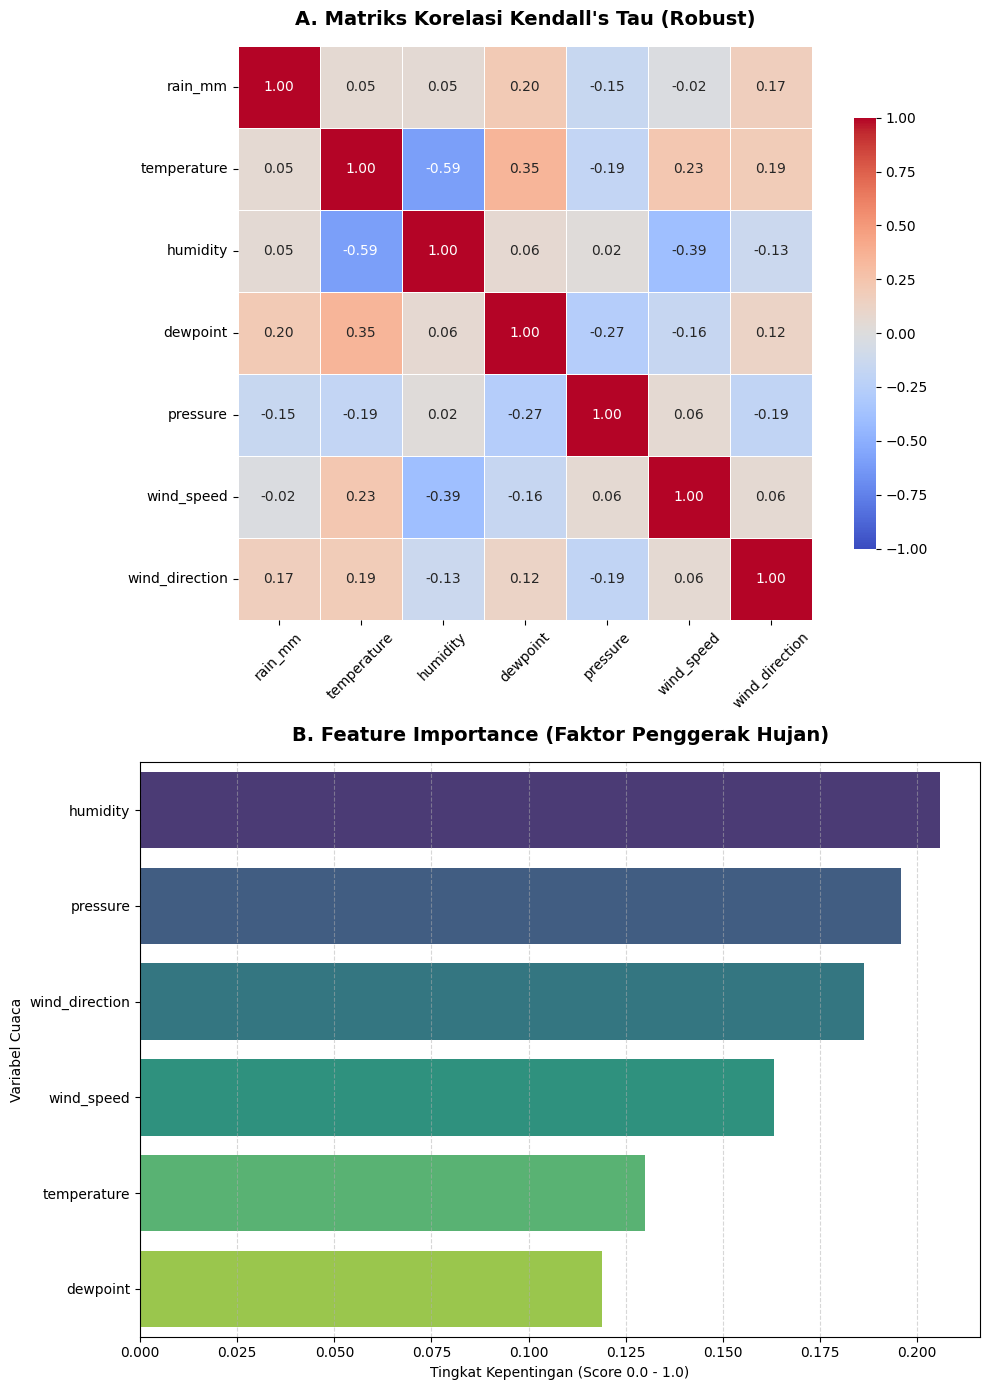

Analisis Selesai!

Top 3 Faktor Paling Berpengaruh terhadap Hujan:
2. humidity (Score: 0.2060)
4. pressure (Score: 0.1959)
6. wind_direction (Score: 0.1863)


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# ==============================================================================
# 1. PERSIAPAN DATA
# ==============================================================================
# Pastikan data bersih
df_clean = df_ai.copy().dropna()

# List fitur
target = 'rain_mm'
# Hapus variabel yang tidak ada di dataframe kamu biar gak error
candidates = [target, 'temperature', 'humidity', 'dewpoint', 'pressure', 'wind_speed', 'wind_direction']
cols_to_plot = [col for col in candidates if col in df_clean.columns]

# Buat Canvas Besar (2 Baris: Atas Heatmap, Bawah Feature Importance)
fig, axes = plt.subplots(2, 1, figsize=(10, 14))

# ==============================================================================
# 2. PLOT A: HEATMAP KORELASI (KENDALL'S TAU)
# ==============================================================================
# Kita pakai 'kendall' karena lebih robust terhadap data hujan yang zero-inflated
corr_matrix = df_clean[cols_to_plot].corr(method='kendall')

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',  # Merah (+) vs Biru (-) lebih mudah dibaca daripada Viridis
            center=0,         # Titik tengah warna di angka 0
            vmin=-1, 
            vmax=1,  # Kunci skala -1 sampai 1
            linewidths=0.5, 
            square=True,
            cbar_kws={"shrink": 0.75},
            ax=axes[0])       # Taruh di gambar atas

axes[0].set_title("A. Matriks Korelasi Kendall's Tau (Robust)", fontsize=14, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=45)

# ==============================================================================
# 3. PLOT B: FEATURE IMPORTANCE (RANDOM FOREST)
# ==============================================================================
# Pisahkan X (Fitur) dan y (Target Hujan)
X = df_clean[cols_to_plot].drop(columns=[target])
y = df_clean[target]

# Latih Model Random Forest Sebentar (Hanya untuk intip fitur penting)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X, y)

# Ambil skor importance
importances = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Bar Chart
sns.barplot(x='Importance', y='Fitur', data=importances, palette='viridis', ax=axes[1])

axes[1].set_title("B. Feature Importance (Faktor Penggerak Hujan)", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Tingkat Kepentingan (Score 0.0 - 1.0)")
axes[1].set_ylabel("Variabel Cuaca")
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

# ==============================================================================
# 4. FINISHING
# ==============================================================================
plt.tight_layout()

# Simpan gambar HD
plt.savefig('analisis_fitur_lengkap.png', dpi=300, bbox_inches='tight') 
plt.show()

# Print text hasil biar bisa dicopas ke naskah
print("Analisis Selesai!")
print("\nTop 3 Faktor Paling Berpengaruh terhadap Hujan:")
for i, row in importances.head(3).iterrows():
    print(f"{i+1}. {row['Fitur']} (Score: {row['Importance']:.4f})")

In [11]:
# =========================================================
# DATA PREPROCESSING UNTUK ENSEMBLE TREE-BASED
# =========================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. SIAPKAN DATAFRAME
df_ensemble = df_ai.sort_index().copy()

# --- [A] REKAYASA FITUR SIKLUS WAKTU ---
df_ensemble['hour_sin'] = np.sin(2 * np.pi * df_ensemble.index.hour / 24)
df_ensemble['hour_cos'] = np.cos(2 * np.pi * df_ensemble.index.hour / 24)
df_ensemble['month_sin'] = np.sin(2 * np.pi * df_ensemble.index.month / 12)
df_ensemble['month_cos'] = np.cos(2 * np.pi * df_ensemble.index.month / 12)

# --- [B] REKAYASA FITUR SIKLUS ANGIN ---
wd_rad = df_ensemble['wind_direction'] * np.pi / 180
df_ensemble['wd_sin'] = np.sin(wd_rad)
df_ensemble['wd_cos'] = np.cos(wd_rad)

# 2. PILIH FITUR
fitur_input = [
    'temperature', 'humidity', 'dewpoint', 'pressure', 'wind_speed',
    'wd_sin', 'wd_cos',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'rain_mm' 
]

target_col = 'rain_mm'
data_values = df_ensemble[fitur_input].values 

# 3. SCALING (MinMax 0-1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_values)

target_idx = fitur_input.index(target_col) 

# 4. FUNGSI WINDOWING (Disamakan dengan LSTM)
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)]) 
        y.append(data[i + seq_length, target_idx]) 
    return np.array(X), np.array(y)

# 5. EKSEKUSI PEMBAGIAN DATA
TIME_STEPS = 24  
X, y = create_sequences(scaled_data, TIME_STEPS)

# Split 80% Train, 20% Test
split_idx = int(len(X) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 6. FLATTENING (Ubah 3D menjadi 2D untuk Ensemble)
num_train, steps, feats = X_train.shape
num_test, _, _ = X_test.shape

X_train_flat = X_train.reshape(num_train, steps * feats)
X_test_flat = X_test.reshape(num_test, steps * feats)
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

# 7. VERIFIKASI HASIL
print("-" * 50)
print("Preprocessing Data untuk Ensemble Selesai!")
print(f"Total Fitur Asli      : {len(fitur_input)} variabel")
print(f"Shape X_train (3D)    : {X_train.shape} (Hanya sebagai basis)")
print(f"Shape X_train_flat    : {X_train_flat.shape} (Input Model Ensemble)")
print(f"Shape y_train_flat    : {y_train_flat.shape} (Target Model Ensemble)")
print(f"Total Kolom Input     : {steps * feats} kolom (Time_steps * Fitur)")
print("-" * 50)

--------------------------------------------------
Preprocessing Data untuk Ensemble Selesai!
Total Fitur Asli      : 12 variabel
Shape X_train (3D)    : (182323, 24, 12) (Hanya sebagai basis)
Shape X_train_flat    : (182323, 288) (Input Model Ensemble)
Shape y_train_flat    : (182323,) (Target Model Ensemble)
Total Kolom Input     : 288 kolom (Time_steps * Fitur)
--------------------------------------------------


In [12]:
import time
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Memulai Training Mode GPU (XGBoost, LightGBM, CatBoost)...")
start_time = time.time()

# --- 1. Definisi Model ---
xgb_gpu = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.005,
    max_depth=10,
    tree_method='hist',
    device='cuda',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

lgbm_gpu = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.005,
    num_leaves=31,
    device='gpu',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cat_gpu = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.005,
    depth=10,
    task_type="GPU",
    devices='0',
    verbose=0,
    random_state=42
)

# --- 2. Voting Regressor ---
model_gpu = VotingRegressor([
    ('xgb', xgb_gpu),
    ('lgbm', lgbm_gpu),
    ('cat', cat_gpu)
])

# --- 3. Training ---
print("Sedang melatih model... (Tunggu sebentar)")
model_gpu.fit(X_train_flat, y_train_flat)

durasi = time.time() - start_time
print(f"Training selesai dalam {durasi:.2f} detik.")

# ==============================================================================
# EVALUASI PERFORMA MASING-MASING MODEL & ENSEMBLE
# ==============================================================================
print("\n--- LAPORAN EVALUASI MODEL ---")

# FUNGSI BANTUAN UNTUK INVERSE SCALING
# Karena scaler dilatih dengan banyak fitur, kita pakai trik dummy array
def inverse_target(scaled_values, scaler_obj, t_idx, total_feats):
    # Buat matrix nol berukuran (jumlah baris data, jumlah fitur)
    dummy = np.zeros((len(scaled_values), total_feats))
    # Masukkan nilai target ke kolom yang sesuai
    dummy[:, t_idx] = scaled_values
    # Lakukan inverse ke seluruh matrix, lalu ekstrak kembali kolom targetnya
    return scaler_obj.inverse_transform(dummy)[:, t_idx]

# Ambil jumlah total fitur dari tahap preprocessing sebelumnya
total_fitur = len(fitur_input)

# Persiapkan data test aktual untuk evaluasi (Kembalikan ke satuan mm)
y_test_real = inverse_target(y_test_flat, scaler, target_idx, total_fitur)

# Daftar model untuk dievaluasi
# model_gpu.estimators_ berisi model yang sudah dilatih di dalam VotingRegressor
daftar_model = [
    ('XGBoost Single', model_gpu.estimators_[0]),
    ('LightGBM Single', model_gpu.estimators_[1]),
    ('CatBoost Single', model_gpu.estimators_[2]),
    ('Ensemble (Voting)', model_gpu)
]

print(f"{'MODEL':<20} | {'MAE (mm)':<10} | {'RMSE (mm)':<10} | {'R2 Score':<10}")
print("-" * 60)

for nama, model in daftar_model:
    # 1. Prediksi (Hasil masih skala 0-1)
    pred_scaled = model.predict(X_test_flat)
    
    # 2. Kembalikan ke satuan asli (mm) menggunakan fungsi bantuan
    pred_real = inverse_target(pred_scaled, scaler, target_idx, total_fitur)
    
    # 3. Hitung Metrik Evaluasi
    mae = mean_absolute_error(y_test_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
    r2 = r2_score(y_test_real, pred_real)
    
    # 4. Tampilkan Hasil
    print(f"{nama:<20} | {mae:<10.4f} | {rmse:<10.4f} | {r2:<10.4f}")

print("-" * 60)

Memulai Training Mode GPU (XGBoost, LightGBM, CatBoost)...
Sedang melatih model... (Tunggu sebentar)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:20:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training selesai dalam 96.07 detik.

--- LAPORAN EVALUASI MODEL ---
MODEL                | MAE (mm)   | RMSE (mm)  | R2 Score  
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [10:21:36] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBoost Single       | 0.2819     | 0.8175     | 0.3336    


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM Single      | 0.2739     | 0.7927     | 0.3734    
CatBoost Single      | 0.2752     | 0.8042     | 0.3551    


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Ensemble (Voting)    | 0.2756     | 0.7986     | 0.3640    
------------------------------------------------------------


In [13]:
# ==============================================================================
# LANGKAH PERANTARA: MEMBUAT PREDIKSI (WAJIB DIJALANKAN)
# ==============================================================================

print("Sedang menghitung prediksi...")

# 1. Lakukan Prediksi (Gunakan 'model_gpu' jika pakai GPU, atau 'model' jika CPU)
# Kita coba deteksi otomatis model mana yang ada
if 'model_gpu' in globals():
    model_aktif = model_gpu
    print("Menggunakan Model GPU")
else:
    model_aktif = model
    print("Menggunakan Model CPU/Standard")

y_pred_scaled = model_aktif.predict(X_test_flat)

# 2. Inverse Transform (Kembalikan ke satuan mm asli)
# Karena menggunakan satu scaler untuk semua fitur, kita buat matriks dummy
total_fitur = len(fitur_input)

# Buat matriks dummy untuk y_pred (hasil prediksi)
dummy_pred = np.zeros((len(y_pred_scaled), total_fitur))
dummy_pred[:, target_idx] = y_pred_scaled
y_pred_final = scaler.inverse_transform(dummy_pred)[:, target_idx]

# Buat matriks dummy untuk y_test (nilai aktual)
dummy_test = np.zeros((len(y_test_flat), total_fitur))
dummy_test[:, target_idx] = y_test_flat
y_test_final = scaler.inverse_transform(dummy_test)[:, target_idx]

# (Opsional) Jika tadi pakai Log Transform, aktifkan baris ini:
# y_pred_final = np.expm1(y_pred_final)
# y_test_final = np.expm1(y_test_final)

print("Variabel 'y_test_final' dan 'y_pred_final' sudah siap!")
print(f"Contoh Prediksi : {y_pred_final[:5]}")

Sedang menghitung prediksi...
Menggunakan Model GPU


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Variabel 'y_test_final' dan 'y_pred_final' sudah siap!
Contoh Prediksi : [0.42130375 0.57286127 0.86113979 0.16953121 0.16822633]


EVALUASI PERFORMA MODEL (METEOROLOGI STANDARD)

[1] Ketepatan Angka (Regression Metrics):
   - MAE (Rata-rata Meleset) : 0.276 mm
   - RMSE (Kesalahan Besar)  : 0.799 mm
   - R² (Kecocokan Pola)     : 0.364 (Max 1.0)

[2] Metrik Hidrologi (Scientific):
   - Korelasi Pearson (r)    : 0.604
   - KGE Score               : 0.460
     (> 0.5 = Bagus, > 0.7 = Sangat Bagus, 1.0 = Sempurna)

[3] Kemampuan Deteksi Hujan (Threshold > 1.0 mm):
   - POD (Probability of Detection): 43.58% (Makin tinggi makin jago deteksi hujan)
   - FAR (False Alarm Ratio)       : 52.07% (Makin rendah makin jujur)
   - CSI (Critical Success Index)  : 29.58% (Gabungan)


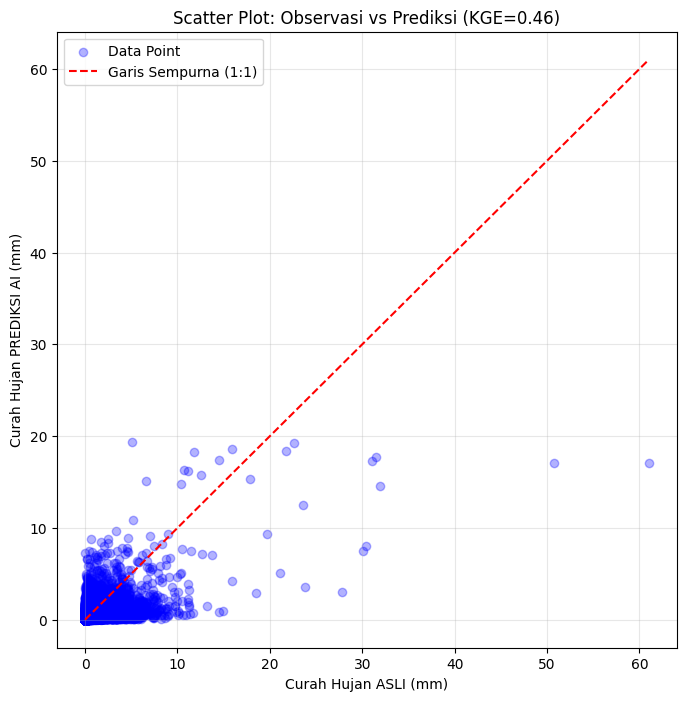

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

def evaluasi_pro(y_true, y_pred, threshold_hujan=1.0):
    print("="*50)
    print("EVALUASI PERFORMA MODEL (METEOROLOGI STANDARD)")
    print("="*50)

    # --- 1. METRIK REGRESI (STANDAR) ---
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n[1] Ketepatan Angka (Regression Metrics):")
    print(f"   - MAE (Rata-rata Meleset) : {mae:.3f} mm")
    print(f"   - RMSE (Kesalahan Besar)  : {rmse:.3f} mm")
    print(f"   - R² (Kecocokan Pola)     : {r2:.3f} (Max 1.0)")

    # --- 2. METRIK HIDROLOGI (KGE - Kling-Gupta Efficiency) ---
    # Ini "Gold Standard" di penelitian air/hujan.
    # KGE mengukur: Korelasi, Bias, dan Variabilitas sekaligus.
    r_correlation = np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]
    alpha = np.std(y_pred) / np.std(y_true)
    beta = np.mean(y_pred) / np.mean(y_true)
    kge = 1 - np.sqrt((r_correlation - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    print(f"\n[2] Metrik Hidrologi (Scientific):")
    print(f"   - Korelasi Pearson (r)    : {r_correlation:.3f}")
    print(f"   - KGE Score               : {kge:.3f}")
    print(f"     (> 0.5 = Bagus, > 0.7 = Sangat Bagus, 1.0 = Sempurna)")

    # --- 3. METRIK DETEKSI (KLASIFIKASI TURUNAN) ---
    # Kita ubah angka jadi status: "Hujan" (>1mm) atau "Tidak" (<1mm)
    # Tujuannya: Cek apakah AI bisa tau KAPAN hujan, meski angkanya meleset dikit.
    y_true_class = (y_true > threshold_hujan).astype(int)
    y_pred_class = (y_pred > threshold_hujan).astype(int)

    print(f"\n[3] Kemampuan Deteksi Hujan (Threshold > {threshold_hujan} mm):")
    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_true_class, y_pred_class).ravel()
    
    # Metrik Peringatan Dini
    pod = tp / (tp + fn + 1e-10) # Probability of Detection (Sensitivitas)
    far = fp / (fp + tp + 1e-10) # False Alarm Ratio (Sering bohong ga?)
    csi = tp / (tp + fn + fp + 1e-10) # Critical Success Index

    print(f"   - POD (Probability of Detection): {pod:.2%} (Makin tinggi makin jago deteksi hujan)")
    print(f"   - FAR (False Alarm Ratio)       : {far:.2%} (Makin rendah makin jujur)")
    print(f"   - CSI (Critical Success Index)  : {csi:.2%} (Gabungan)")
    
    # --- 4. VISUALISASI SCATTER PLOT ---
    plt.figure(figsize=(8, 8))
    plt.scatter(y_true, y_pred, alpha=0.3, color='blue', label='Data Point')
    
    # Garis Identitas (Target Sempurna)
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Garis Sempurna (1:1)')
    
    plt.title(f"Scatter Plot: Observasi vs Prediksi (KGE={kge:.2f})")
    plt.xlabel("Curah Hujan ASLI (mm)")
    plt.ylabel("Curah Hujan PREDIKSI AI (mm)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- CARA PAKAI ---
# Pastikan y_test_final dan y_pred_final sudah ada dari sel sebelumnya
evaluasi_pro(y_test_final, y_pred_final)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 0.28 mm
R2 : 0.3640


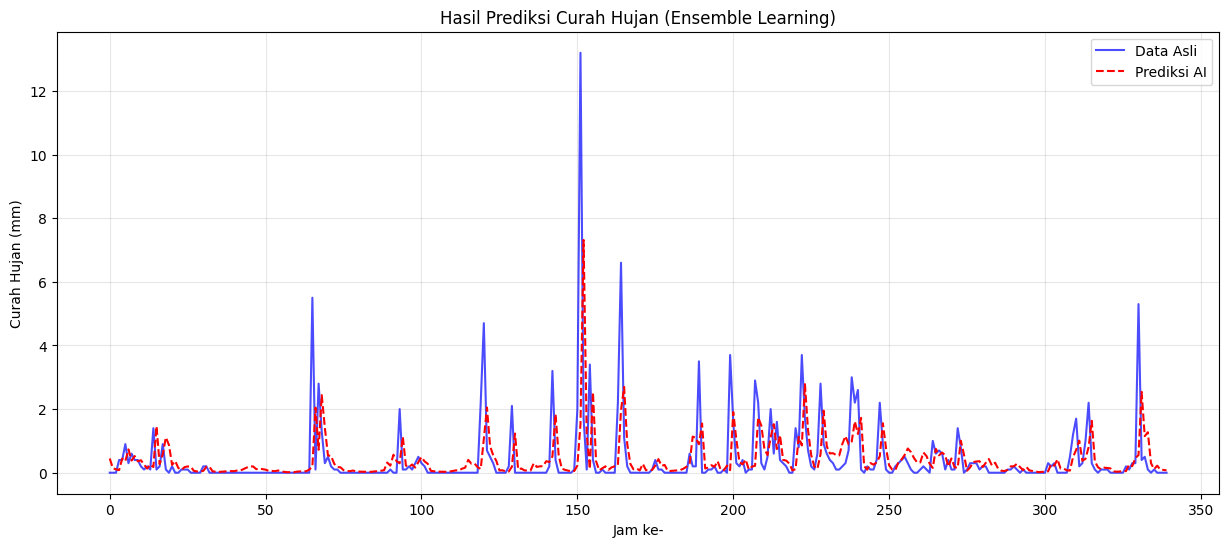

In [15]:
# 1. Prediksi
y_pred_scaled = model_gpu.predict(X_test_flat)

# 2. Kembalikan ke Satuan Asli (mm)
# Gunakan matriks dummy karena scaler dilatih dengan banyak fitur
total_fitur = len(fitur_input)

# Inverse untuk prediksi
dummy_pred = np.zeros((len(y_pred_scaled), total_fitur))
dummy_pred[:, target_idx] = y_pred_scaled
y_pred_final = scaler.inverse_transform(dummy_pred)[:, target_idx]

# Inverse untuk data aktual (test)
dummy_test = np.zeros((len(y_test_flat), total_fitur))
dummy_test[:, target_idx] = y_test_flat
y_test_final = scaler.inverse_transform(dummy_test)[:, target_idx]

# 3. Hitung Skor
print(f"MAE: {mean_absolute_error(y_test_final, y_pred_final):.2f} mm")
print(f"R2 : {r2_score(y_test_final, y_pred_final):.4f}")

# 4. Gambar Grafik
plt.figure(figsize=(15, 6))
# Zoom in ke 240 jam terakhir (10 hari) biar kelihatan detailnya
plt.plot(y_test_final[-340:], label='Data Asli', color='blue', alpha=0.7)
plt.plot(y_pred_final[-340:], label='Prediksi AI', color='red', linestyle='--')
plt.title('Hasil Prediksi Curah Hujan (Ensemble Learning)')
plt.ylabel('Curah Hujan (mm)')
plt.xlabel('Jam ke-')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# 1. Simpan Model Ensemble
joblib.dump(model_gpu, 'model_hujan_ensemble.pkl')

# 2. Simpan Scaler (Hanya ada 1 scaler global)
joblib.dump(scaler, 'scaler_global.pkl')

# 3. Simpan Metadata (Daftar urutan fitur dan posisi target)
metadata = {
    'fitur_input': fitur_input,
    'target_idx': target_idx
}
joblib.dump(metadata, 'metadata_fitur.pkl')

print("Model, Scaler, dan Metadata berhasil disimpan!")

Model, Scaler, dan Metadata berhasil disimpan!
